**Particle in a 1D Harmonic Oscillator**

The code assumed the particle is an electron and we use Atomic Units.

We start importing libraries:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

We use the same parameters (force constant k=1) as in this Chemistry LibreText example https://chem.libretexts.org/Bookshelves/Physical_and_Theoretical_Chemistry_Textbook_Maps/Quantum_Tutorials_(Rioux)/09%3A_Numerical_Solutions_for_Schrodinger's_Equation/9.09%3A_Numerical_Solutions_for_the_Harmonic_Oscillator

In [2]:
#Potential as a function of position V= D[1-exp[-B*(x-xe)]]**2 on D=2 B=1 xe=0
def getV(x):
    potvalue = 2*(1-np.exp(-1*(x-0)))**2
    return potvalue

And now we define a function that calculates the matrix (denoted by F in the theoretical derivation) that encodes the Schrödinger Equation in finite diference form for n points from 0 to n-1

In [3]:
#Discretized Schrodinger equation in n points (FROM 0 to n-1)
def Eq(n,h,x):
    F = np.zeros([n,n])
    for i in range(0,n):
        F[i,i] = -2*((h**2)*getV(x[i]) + 1)
        if i > 0:
           F[i,i-1] = 1
           if i < n-1:
              F[i,i+1] = 1
    return F

Up to now, the code does nothing explicitly. We have just defined how to calculate the potential and how to calculate the matrix F

Let us now start the numerical solution, entering the parameters that we need: the discretization h and the size of the box. You can play with these values to see the effect they have in the numerical method.

In [4]:
xlower = -2
xupper = 12

#Discretization options
h = 0.02  #discretization in space

#Create coordinates at which the solution will be calculated
x = np.arange(xlower,xupper+h,h)
#grid size (how many discrete points to use in the range [-L/2,L/2])
npoints=len(x)
print("Using",npoints, "grid points.")

Using 701 grid points.


Now we can calculate F explicitly and diagonalize. The result of the diagonalization is **not ordered** so we have to order the results (energies and wavefunctions) by energy values.

In [5]:
#Calculation of discrete form of Schrodinger Equation and diagonalization
F=Eq(npoints,h,x)
eigenValues, eigenVectors = np.linalg.eig(F)

#Order results by eigenvalue
# w ordered eigenvalues and vs ordered eigenvectors
idx = eigenValues.argsort()[::-1]
w = eigenValues[idx]
vs = eigenVectors[:,idx]

#Energy Level
E = - w/(2.0*h**2)

Print **Energy Results** for the first energy levels:

In [6]:
#Energy Levels
E = - w/(2.0*h**2)
for k in range(0,5):
  print("n=",k,", E(numeric)=%.4f" %E[k])

n= 0 , E(numeric)=0.8750
n= 1 , E(numeric)=1.8750
n= 2 , E(numeric)=2.0598
n= 3 , E(numeric)=2.2161
n= 4 , E(numeric)=2.4480


Now let us show the Wavefunctions obtained in the diagonalization process

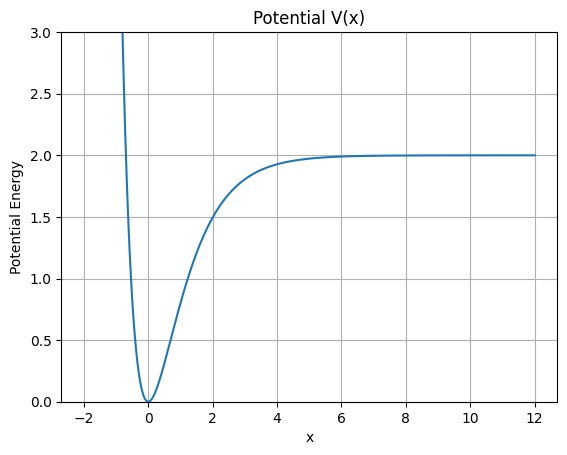

In [7]:
Vx = getV(x)

plt.plot(x, Vx)
plt.ylim(0, 3)
plt.grid(True)
plt.title('Potential V(x)')
plt.xlabel('x')
plt.ylabel('Potential Energy')
plt.show()

Plotting


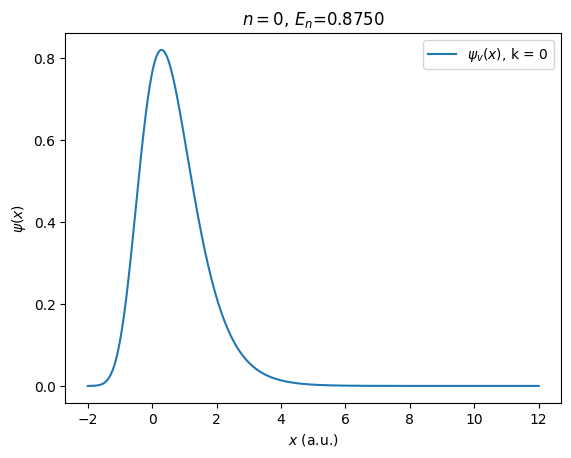

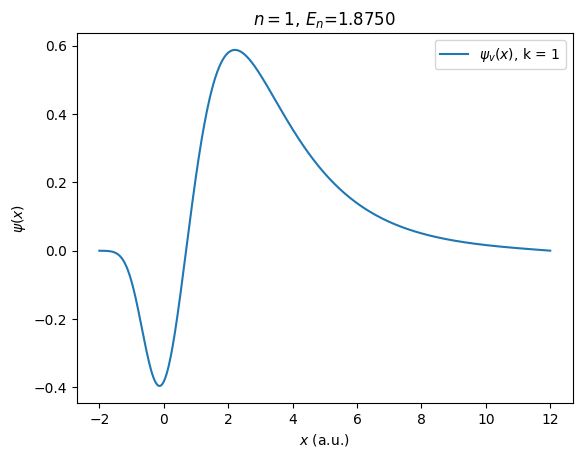

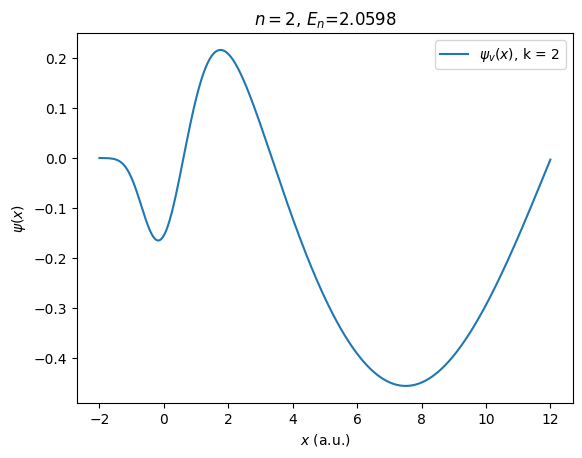

In [8]:
#Init Wavefunction (empty list with npoints elements)
psi = [None]*npoints

#Calculation of normalised Wave Functions
for k in range(0,len(w)):
	psi[k] = vs[:,k]
	integral = h*np.dot(psi[k],psi[k])
	psi[k] = psi[k]/integral**0.5

#Plot Wave functions
print("Plotting")

#v = int(input("\n Quantum Number (enter 0 for ground state):\n>"))
for v in range(0,3):
	plt.plot(x,psi[v],label=r'$\psi_v(x)$, k = ' + str(v))
	plt.title(r'$n=$'+ str(v) + r', $E_n$=' + '{:.4f}'.format(E[v]))
	plt.legend()
	plt.xlabel(r'$x$ (a.u.)')
	plt.ylabel(r'$\psi(x)$')
	plt.show()

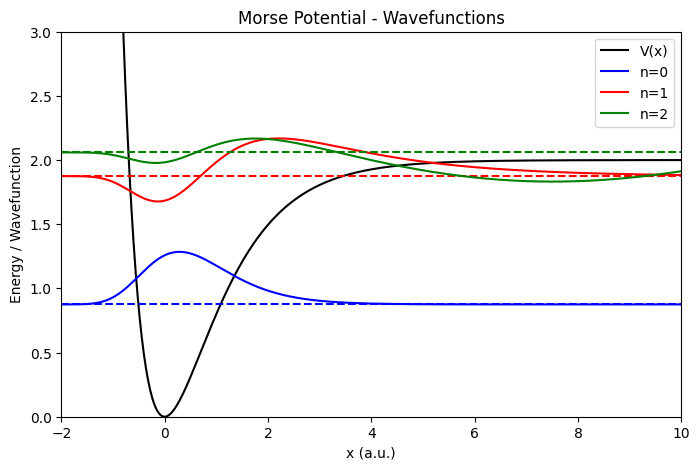

In [18]:
plt.figure(figsize=(8, 5))

# Graficar el potencial
plt.plot(x, Vx, 'k-', label='V(x)')

# Nivel n=0: Wavefunction psi
plt.axhline(E[0], color='blue', linestyle='--')
plt.plot(x, psi[0] * 0.5 + E[0], color='blue', label='n=0')

# Nivel n=1
plt.axhline(E[1], color='red', linestyle='--')
plt.plot(x, psi[1] * 0.5 + E[1], color='red', label='n=1')

# Nivel n=2
plt.axhline(E[2], color='green', linestyle='--')
plt.plot(x, psi[2] * 0.5 + E[2], color='green', label='n=2')

plt.ylim(0, 3)
plt.xlim(-2, 10)
plt.title('Morse Potential - Wavefunctions')
plt.xlabel('x (a.u.)')
plt.ylabel('Energy / Wavefunction')
plt.legend()
plt.show()

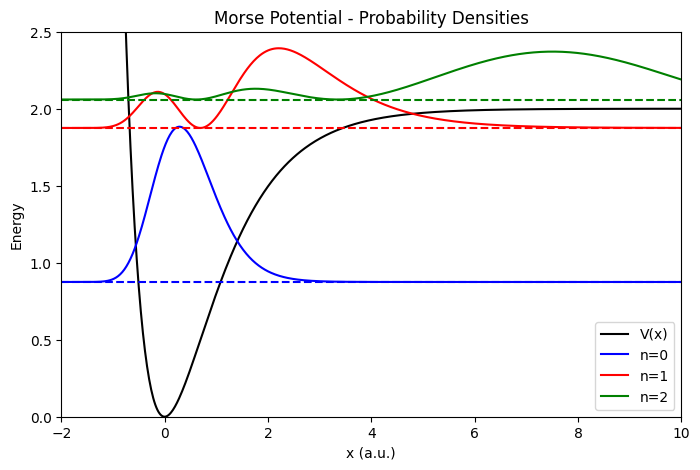

In [20]:

plt.figure(figsize=(8, 5))

# Graficar el potencial
plt.plot(x, Vx, 'k-', label='V(x)')

# Nivel n=0
plt.axhline(E[0], color='blue', linestyle='--')
plt.plot(x, np.abs(psi[0])**2 * 1.5 + E[0], color='blue', label='n=0')

# Nivel n=1
plt.axhline(E[1], color='red', linestyle='--')
plt.plot(x, np.abs(psi[1])**2 * 1.5 + E[1], color='red', label='n=1')

# Nivel n=2
plt.axhline(E[2], color='green', linestyle='--')
plt.plot(x, np.abs(psi[2])**2 * 1.5 + E[2], color='green', label='n=2')

plt.ylim(0, 2.5)
plt.xlim(-2, 10)
plt.title('Morse Potential - Probability Densities')
plt.xlabel('x (a.u.)')
plt.ylabel('Energy')
plt.legend()
plt.show()